In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train, y_test = y_train.flatten(), y_test.flatten()
x_train, x_test = x_train.astype("float32"), x_test.astype("float32")

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

print("Train:", x_train.shape, "| Test:", x_test.shape)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1971s 12us/step
Train: (50000, 32, 32, 3) | Test: (10000, 32, 32, 3)


x_train: (50000, 32, 32, 3) | y_train: (50000,)


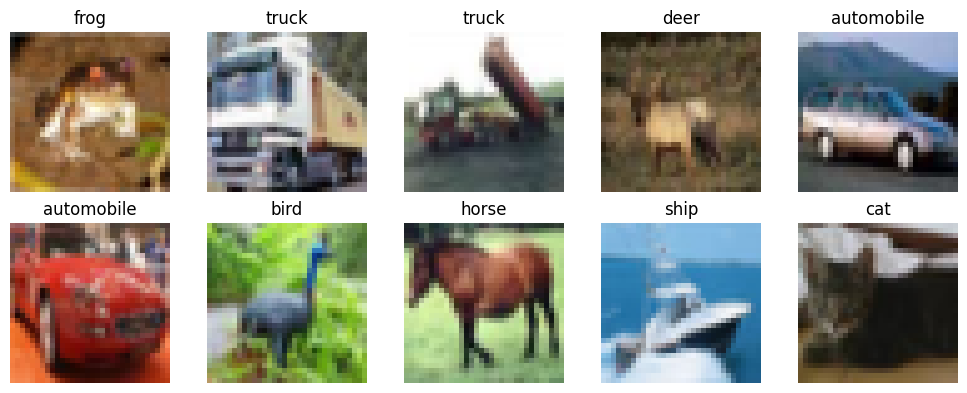

In [2]:
import matplotlib.pyplot as plt

print("x_train:", x_train.shape, "| y_train:", y_train.shape)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].astype("uint8"))
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [3]:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Rescaling(1./255),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),


    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),


    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),


    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),


    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax"),
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403,882 (1.54 MB)

 Trainable params: 403,434 (1.54 MB)

 Non-trainable params: 448 (1.75 KB)

In [4]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=4, restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=25,
    batch_size=64,
    callbacks=[early_stop],
)

Epoch 1/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.2814 - loss: 1.9407 - val_accuracy: 0.3288 - val_loss: 1.9715
Epoch 2/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4063 - loss: 1.6150 - val_accuracy: 0.4480 - val_loss: 1.4675
Epoch 3/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4750 - loss: 1.4442 - val_accuracy: 0.5832 - val_loss: 1.1600
Epoch 4/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5281 - loss: 1.3139 - val_accuracy: 0.5794 - val_loss: 1.2124
Epoch 5/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5700 - loss: 1.2212 - val_accuracy: 0.6156 - val_loss: 1.1279
Epoch 6/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.5973 - loss: 1.1501 - val_accuracy: 0.6332 - val_loss: 1.1260
Epoch 7/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.6269 - loss: 1.0796 - val_accuracy: 0.6392 - val_loss: 1.0335
Epoch 8/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.6439 - loss: 1.0325 - 

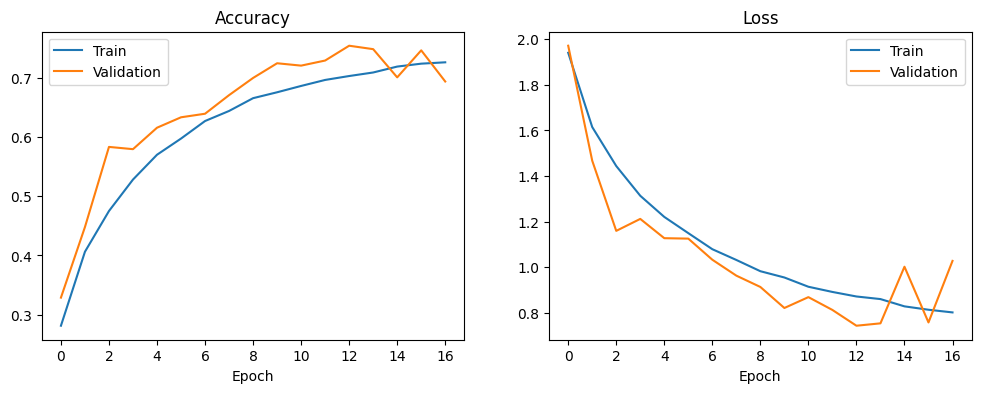

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history["accuracy"], label="Train")
ax[0].plot(history.history["val_accuracy"], label="Validation")
ax[0].set_title("Accuracy"); ax[0].set_xlabel("Epoch"); ax[0].legend()

ax[1].plot(history.history["loss"], label="Train")
ax[1].plot(history.history["val_loss"], label="Validation")
ax[1].set_title("Loss"); ax[1].set_xlabel("Epoch"); ax[1].legend()

plt.show()

Test Accuracy: 74.44%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

    airplane       0.73      0.80      0.76      1000
  automobile       0.84      0.91      0.87      1000
        bird       0.73      0.59      0.65      1000
         cat       0.61      0.50      0.55      1000
        deer       0.81      0.62      0.70      1000
         dog       0.75      0.59      0.66      1000
        frog       0.62      0.89      0.73      1000
       horse       0.88      0.76      0.81      1000
        ship       0.76      0.90      0.82      1000
       truck       0.77      0.89      0.83      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



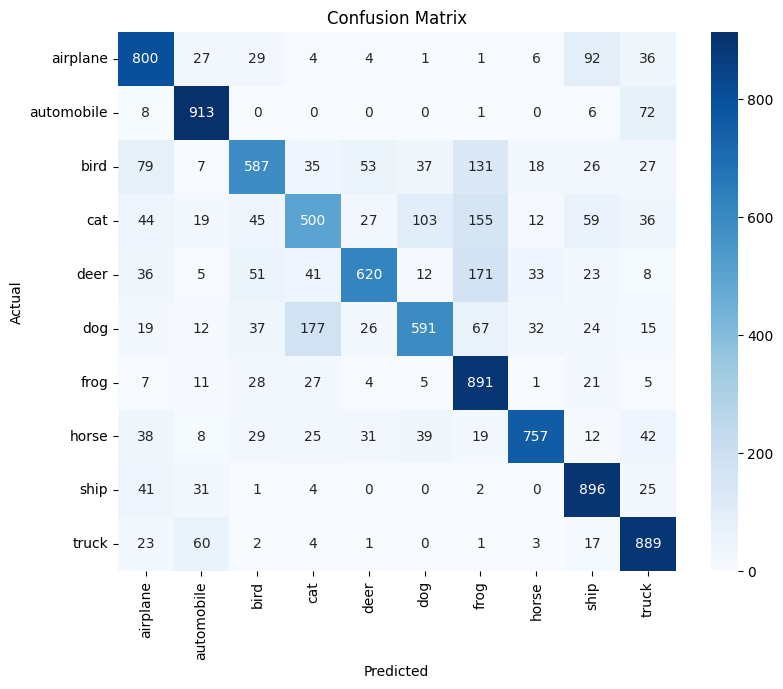

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

y_pred = np.argmax(model.predict(x_test), axis=1)
print(classification_report(y_test, y_pred, target_names=class_names))

plt.figure(figsize=(9, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d",
            cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

In [7]:
model.save("cifar10_cnn.keras")


from google.colab import files
files.download("cifar10_cnn.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
!pip install -q "gradio>=5,<6"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.6/325.6 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.4/462.4 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 8.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hf-gradio 0.4.1 requires gradio-client<3.0,>=2.0, but you have gradio-client 1.14.0 which is incompatible.
google-adk 2.7.1 requires starlette<2,>=1.3.1, but you have starlette 0.52.1 which is incompatible.
python-fasthtml 0.14.12 requires starlette>=1.0.1, but you have

In [9]:
import os
from PIL import Image

os.makedirs("examples", exist_ok=True)
example_paths = []
for i in range(6):
    path = f"examples/{class_names[y_test[i]]}_{i}.png"
    Image.fromarray(x_test[i].astype("uint8")).resize((256, 256)).save(path)
    example_paths.append([path])

In [10]:
import gradio as gr
from PIL import Image

def predict(img):
    if img is None:
        return None
    img = Image.fromarray(img).convert("RGB").resize((32, 32))
    arr = np.expand_dims(np.array(img, dtype="float32"), axis=0)
    probs = model.predict(arr, verbose=0)[0]
    return {class_names[i]: float(probs[i]) for i in range(10)}

theme = gr.themes.Base(
    primary_hue="slate",
    neutral_hue="stone",
    font=[gr.themes.GoogleFont("Playfair Display"), "Georgia", "serif"],
)

css = """
.gradio-container {background-color: #f5f1e8 !important; max-width: 1000px !important; margin: auto;}
#header {text-align: center; padding: 28px 10px 10px 10px; border-bottom: 2px double #2c3e50; margin-bottom: 20px;}
#header h1 {font-family: 'Playfair Display', Georgia, serif; font-size: 2.4rem; color: #1f2d3d; margin: 0;}
#header p {font-style: italic; color: #5d6d7e; margin-top: 8px; font-size: 1.05rem;}
#footer {text-align: center; color: #7b7b7b; font-size: 0.9rem; margin-top: 25px; border-top: 1px solid #c9c2b0; padding-top: 12px;}
button.primary {background: #1f2d3d !important; color: #f5f1e8 !important; border-radius: 4px !important;}
"""

with gr.Blocks(theme=theme, css=css, title="CIFAR-10 Image Classifier") as demo:
    gr.HTML("""
    <div id="header">
        <h1>CIFAR-10 Image Classifier</h1>
        <p>A Convolutional Neural Network for Object Recognition</p>
    </div>
    """)

    with gr.Row():
        with gr.Column():
            inp = gr.Image(label="Upload an Image", type="numpy", height=300)
            with gr.Row():
                clear_btn = gr.ClearButton(components=[inp], value="Clear")
                submit_btn = gr.Button("Classify", variant="primary")
        with gr.Column():
            out = gr.Label(num_top_classes=3, label="Prediction (Top 3)")

    gr.Examples(examples=example_paths, inputs=inp, label="Try a sample image")

    gr.Markdown(f"""
    ### About this model
    - **Architecture:** 3-block CNN with BatchNorm, Dropout and Data Augmentation
    - **Dataset:** CIFAR-10 (60,000 images, 10 classes)
    - **Test Accuracy:** {test_acc*100:.2f}%
    - **Classes:** {", ".join(class_names)}
    """)

    gr.HTML('<div id="footer">Deep Learning Assignment &nbsp;|&nbsp; Built with TensorFlow &amp; Gradio</div>')

    submit_btn.click(predict, inputs=inp, outputs=out)
    inp.change(predict, inputs=inp, outputs=out)

demo.launch(share=True, debug=True)

/tmp/ipykernel_1803/3701957686.py:27: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=theme, css=css, title="CIFAR-10 Image Classifier") as demo:
/tmp/ipykernel_1803/3701957686.py:27: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(theme=theme, css=css, title="CIFAR-10 Image Classifier") as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ab5df1051008e5789d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://ab5df1051008e5789d.gradio.live
